![image.png](https://i.imgur.com/a3uAqnb.png)

# 1. Basic image reading/writing
# BEGIN
1. Set image path (e.g., "Lena.jpg")

2. Read image using PIL:
- Open file and convert to RGB
- Convert to NumPy array

3. Read image using OpenCV:
- Read as BGR format
- Convert BGR → RGB
- Compare with PIL array to check equality

4. Write image using PIL:
- Save as "out_pil.jpg"

5. Write image using OpenCV:
- Save directly (wrong colors, BGR expected)
- Convert RGB → BGR and save (correct colors)

6. Verify outputs:
- Load both wrong and correct images
- Compare pixel arrays for equality
# END


In [23]:
import cv2
from PIL import Image
image_path = 'Lena.jpg'

pil_image = Image.open(image_path).convert('RGB')
pil_array = np.array(pil_image)

cv2_img = cv2.imread(image_path)
cv2_rgb = cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB)

print ('Images are same?', np.allclose(pil_array, cv2_img))

Images are same? False


# 2. Amplitude, Pixel intensity
# BEGIN
1. Load grayscale image
- Open file and convert to mode "L" (grayscale)
- Convert to NumPy array

2. Pick a pixel coordinate (x=50, y=100)
- Access pixel intensity from grayscale array
- Print grayscale amplitude value

3. Load color image
- Open file and convert to mode "RGB"
- Convert to NumPy array

4. Pick the same pixel coordinate
- Access pixel values [R, G, B] from color array
- Print color amplitude vector

5. Display both images with marked pixel
- Show grayscale image with red marker at (x, y)
- Show color image with red marker at (x, y)
# END

Grayscale amplitude at 50, 100: 104
Colour amplitude at 50, 100: [180  71  74] [R, G, B]


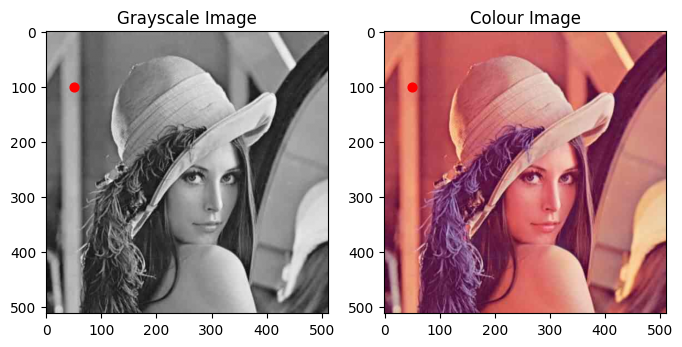

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

gray_img = Image.open('Lena.jpg').convert('L')
gray_array = np.array(gray_img)

x, y = 50, 100 # f(x,y)
amplitude_gray = gray_array[x, y]
print (f'Grayscale amplitude at {x}, {y}: {amplitude_gray}')

colour_img = Image.open('Lena.jpg').convert('RGB')
colour_array = np.array(colour_img)

x, y = 50, 100
amplitude_colour = colour_array[x, y]
print (f'Colour amplitude at {x}, {y}: {amplitude_colour} [R, G, B]')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
ax1.imshow(gray_array, cmap='gray')
ax1.scatter([x], [y], c='red', s=40)
ax1.set_title('Grayscale Image')

ax2.imshow(colour_array)
ax2.scatter([x], [y], c='red', s=40)
ax2.set_title('Colour Image')

plt.show()

# 3. Triangular inequality
# BEGIN
1. Define three points p, q, z (1,1), (4,1), (4,3)
2. Plot p, q, z on a 2D grid
3. Draw direct line from p → z (blue)
4. Draw indirect path p → q → z (red dashed)
5. Add title, legend, grid, and show plot
# END

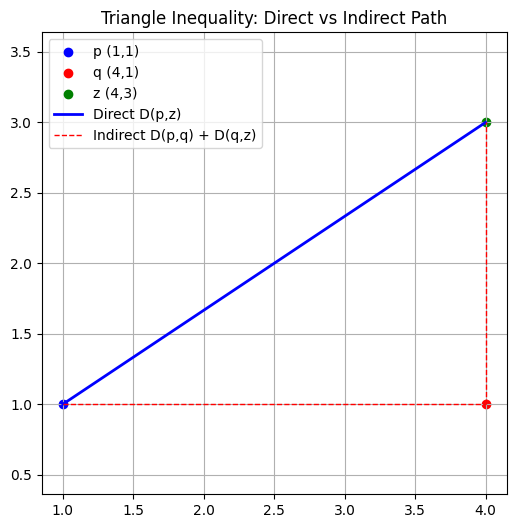

In [25]:
import matplotlib.pyplot as plt
p = (1, 1)
q = (4, 1)
z = (4, 3)

plt.figure(figsize=(6,6))

plt.scatter(*p, color='blue', label='p (1,1)')
plt.scatter(*q, color='red', label ='q (4,1)')
plt.scatter(*z, color='green', label='z (4,3)')

plt.plot([p[0], z[0]], [p[1], z[1]], 'b-', linewidth=2, label='Direct D(p,z)')

plt.plot([p[0], q[0]], [p[1], q[1]], 'r--', linewidth=1)
plt.plot([q[0], z[0]], [q[1], z[1]], 'r--', linewidth=1, label='Indirect D(p,q) + D(q,z)')

plt.title('Triangle Inequality: Direct vs Indirect Path')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# 4. Distances Computation
# BEGIN
1. Define points p=(2,2), q=(6,5)

2. Compute Euclidean distance:
       sqrt((x1-x2)^2 + (y1-y2)^2)

3. Compute Manhattan distance:
       |x1-x2| + |y1-y2|

4. Compute Chessboard distance:
       max(|x1-x2|, |y1-y2|)

5. Print all three distances
6. Plot p and q
    - Draw direct line (Euclidean)
    - Show grid path (Manhattan)
    - Show diagonal relation (Chessboard)
# END

Ecclidean distance: 5.00
Manhattan distance: 7.00
Chessboard distance: 4.00


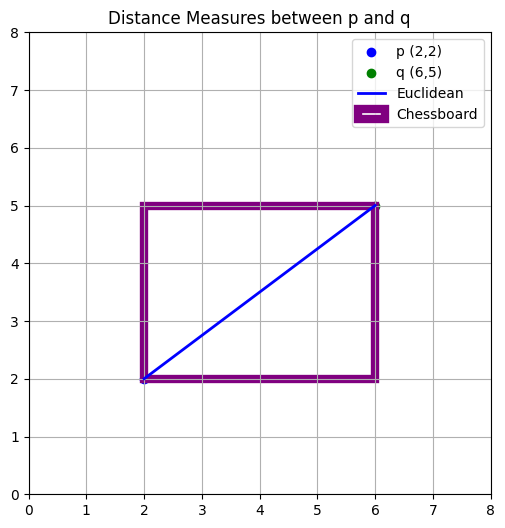

In [28]:
import numpy as np
import matplotlib.pyplot as plt

p = (2,2)
q = (6,5)

euclidean = np.sqrt((p[0]-q[0])**2 + (p[1]-q[1])**2)
manhattan = abs(p[0] - q[0]) + abs(p[1] - q[1])
chessboard = max(abs(p[0]-q[0]), abs(p[1]-q[1]))

print (f'Ecclidean distance: {euclidean:.2f}')
print (f'Manhattan distance: {manhattan:.2f}')
print (f'Chessboard distance: {chessboard:.2f}')

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(*p, color='blue', label='p (2,2)')
ax.scatter(*q, color='green', label='q (6,5)')

ax.plot([p[0], q[0]], [p[1], q[1]], 'b-', linewidth=2, label="Euclidean")

ax.plot([p[0], p[0]], [p[1], q[1]], 'r--', linewidth=2)
ax.plot([p[0], q[0]], [p[1], q[1]], 'r--', linewidth=2, label="Manhattan")

rect = plt.Rectangle((min(p[0], q[0]), min(p[1], q[1])),
                     abs(p[0]-q[0]), abs(p[1]-q[1]),
                     fill=False, edgecolor="purple", linestyle="-", linewidth=6, label="Chessboard")
ax.add_patch(rect)

ax.legend()
ax.grid(True)
ax.set_aspect('equal')
ax.set_title("Distance Measures between p and q")
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
plt.show()

# 5. Adding/averaging noise in images
# BEGIN
1. Load grayscale image
- Read image in grayscale mode
- Resize image to 128x128 for speed

2. Define function to add Gaussian noise
- Generate noise with given mean and standard deviation
- Add noise to image pixel values
- Clip results to range [0, 255] and convert to uint8

3. Generate K noisy images
- Repeat noise function K times
- Store noisy images in a list

4. Average noisy images
- Compute mean pixel value across all K noisy images
- Convert result to uint8 for display

5. Display results
- Show original image
- Show one noisy image sample
- Show averaged image (with K noisy images)
# END


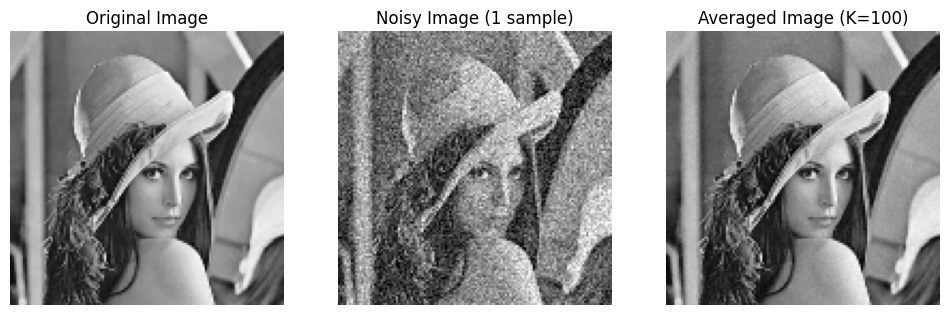

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Lena.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128,128))

def add_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.float32)
    noisy_img = cv2.add(image.astype(np.float32), noise)
    return np.clip(noisy_img, 0, 255).astype(np.uint8)

K = 25
noisy_images = [add_noise(img) for _ in range(K)]


avg_image = np.mean(noisy_images, axis=0).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(12,4))

axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(noisy_images[0], cmap="gray")
axs[1].set_title("Noisy Image (1 sample)")
axs[1].axis("off")

axs[2].imshow(avg_image, cmap="gray")
axs[2].set_title(f"Averaged Image (K={K})")
axs[2].axis("off")

plt.show()

# Histogram computation
# BEGIN
1. Load grayscale image
- Read image from file in grayscale mode

2. Compute histogram
- Flatten image into 1D array
- Use np.histogram with 256 bins (0–255 intensity levels)

3. Compute cumulative distribution function (CDF)
- Take cumulative sum of histogram i.e., how many pixels have intensity ≤ a given value.
- Normalize CDF for plotting by scaling to histogram max value

4. Plot results
- Plot normalized CDF in blue
- Plot histogram in red
- Set x-axis range from 0 to 256
- Add legend ("cdf", "histogram")
- Show the combined plot
# END


/tmp/ipython-input-3735031585.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten (),256,[0,256], color = 'r')


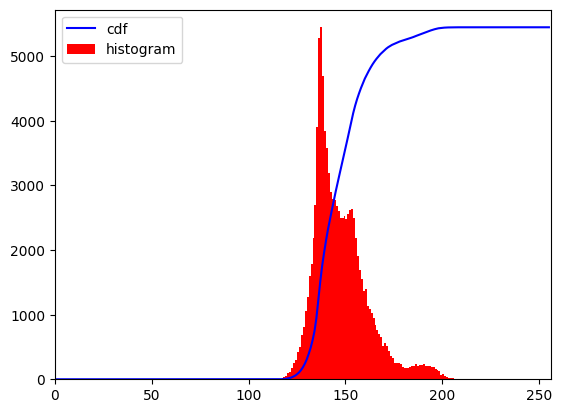

In [30]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('wiki.jpg', cv2.IMREAD_GRAYSCALE)
hist,bins = np.histogram(img.flatten (),256,[0,256])

cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max ()) / cdf.max()

plt.plot(cdf_normalized , color = 'b')
plt.hist(img.flatten (),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

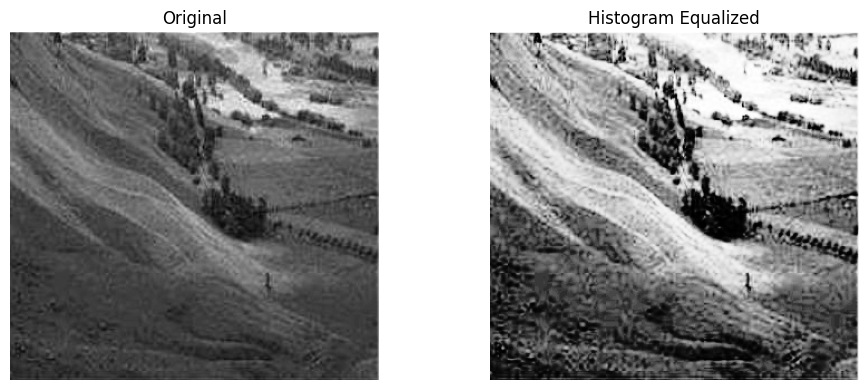

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("wiki.jpg", cv2.IMREAD_GRAYSCALE)
assert img is not None, "Image not found. Check the path/filename."

equ = cv2.equalizeHist(img)
res = np.hstack((img, equ))
cv2.imwrite("res.png", res)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(equ, cmap="gray")
axs[1].set_title("Histogram Equalized")
axs[1].axis("off")

plt.tight_layout()
plt.show()

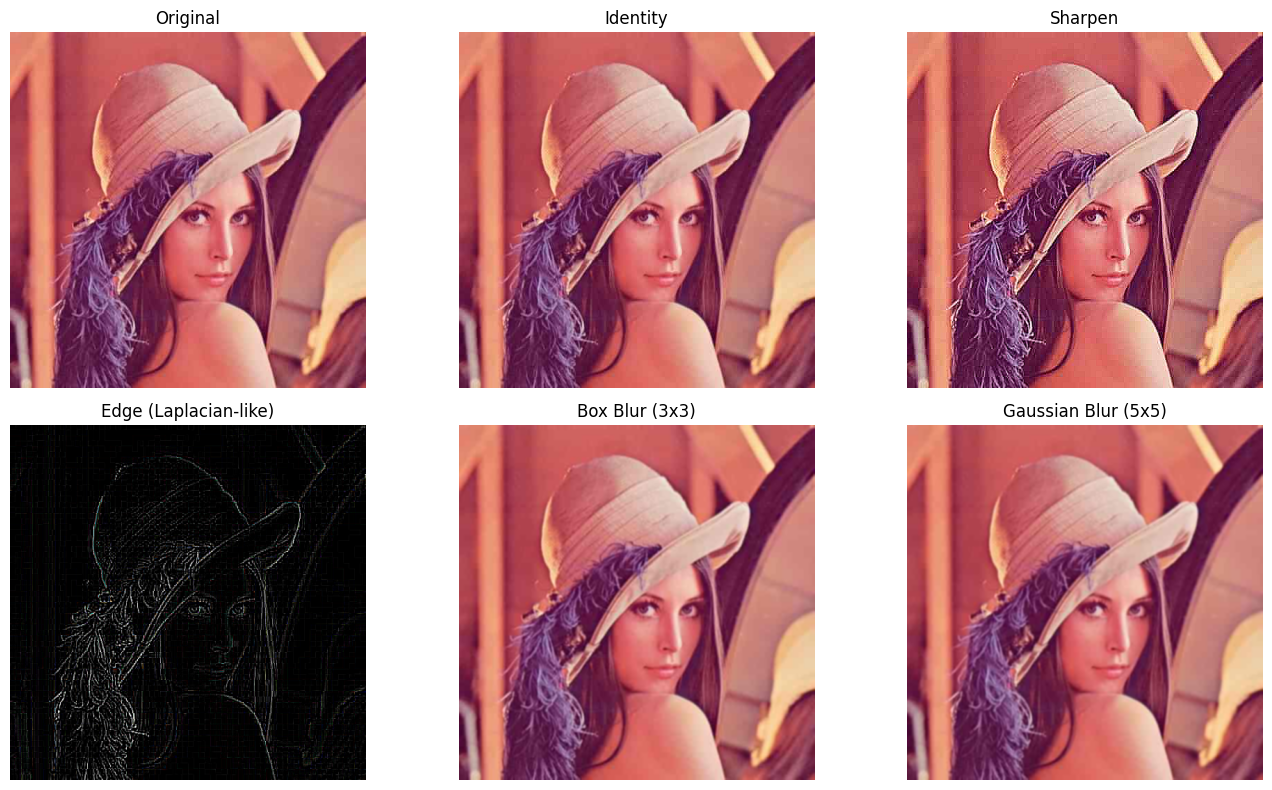

True

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv2.imread("Lena.jpg", cv2.IMREAD_COLOR)
assert img_bgr is not None, "Image not found. Use a valid path."

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

identity = np.array([[0,0,0],
                     [0,1,0],
                     [0,0,0]], dtype=np.float32)

sharpen = np.array([[ 0,-1, 0],
                    [-1, 5,-1],
                    [ 0,-1, 0]], dtype=np.float32)

edge = np.array([[-1,-1,-1],
                   [-1, 8,-1],
                   [-1,-1,-1]], dtype=np.float32)

box_blur = (1/9.0) * np.ones((3,3), dtype=np.float32)

# For Gaussian blur, we cvan also use cv2.GaussianBlur,
gauss5 = (1/256.0) * np.array(
    [[ 1,  4,  6,  4,  1],
     [ 4, 16, 24, 16,  4],
     [ 6, 24, 36, 24,  6],
     [ 4, 16, 24, 16,  4],
     [ 1,  4,  6,  4,  1]], dtype=np.float32
)

# ---------- 3) Apply kernels (grayscale and color versions) ----------
# OpenCV’s filter2D works per-channel; safe for RGB/BGR arrays too.
def apply_kernel_color(img_rgb, kernel):
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    out_bgr = cv2.filter2D(bgr, ddepth=-1, kernel=kernel)
    return cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)

id_img   = apply_kernel_color(img_rgb, identity)
sharp    = apply_kernel_color(img_rgb, sharpen)
edge     = apply_kernel_color(img_rgb, edge)
box      = apply_kernel_color(img_rgb, box_blur)
gauss    = apply_kernel_color(img_rgb, gauss5)

# Alternatives (built-ins):
# box_alt   = cv2.cvtColor(cv2.blur(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), (3,3)), cv2.COLOR_BGR2RGB)
# gauss_alt = cv2.cvtColor(cv2.GaussianBlur(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), (5,5), 0), cv2.COLOR_BGR2RGB)

titles = [
    "Original", "Identity", "Sharpen", "Edge (Laplacian-like)",
    "Box Blur (3x3)", "Gaussian Blur (5x5)"
]
images = [img_rgb, id_img, sharp, edge, box, gauss]

plt.figure(figsize=(14,8))
for i, (t, im) in enumerate(zip(titles, images), 1):
    plt.subplot(2, 3, i)
    plt.imshow(im)
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()

cv2.imwrite("out_identity.jpg", cv2.cvtColor(id_img, cv2.COLOR_RGB2BGR))
cv2.imwrite("out_sharpen.jpg",  cv2.cvtColor(sharp,  cv2.COLOR_RGB2BGR))
cv2.imwrite("out_edge.jpg",     cv2.cvtColor(edge,   cv2.COLOR_RGB2BGR))
cv2.imwrite("out_boxblur.jpg",  cv2.cvtColor(box,    cv2.COLOR_RGB2BGR))
cv2.imwrite("out_gaussian.jpg", cv2.cvtColor(gauss,  cv2.COLOR_RGB2BGR))
